In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model evaluation
from sklearn.metrics import r2_score, mean_squared_error

# Data splitting
from sklearn.model_selection import train_test_split

In [2]:
rain_df = pd.read_csv("../data/processed/rainfall_clean.csv")

rain_df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


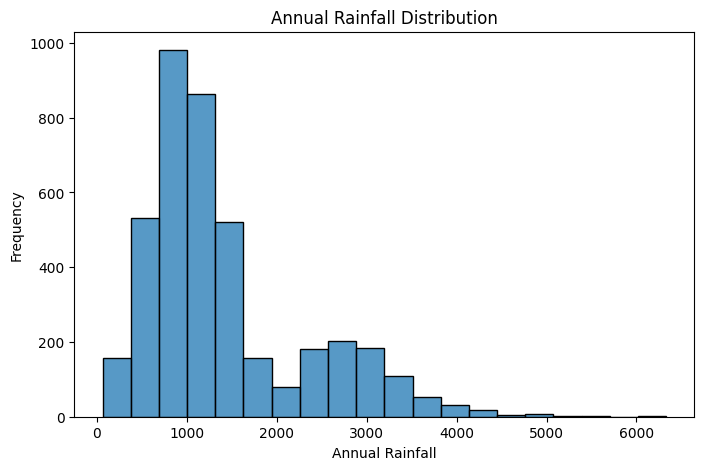

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(rain_df['ANNUAL'], bins=20)

plt.title("Annual Rainfall Distribution")

plt.xlabel("Annual Rainfall")

plt.ylabel("Frequency")

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = rain_df[['JUN','JUL','AUG','SEP']]

y = rain_df['ANNUAL']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score


models = {

"Linear Regression": LinearRegression(),

"Decision Tree": DecisionTreeRegressor(),

"Random Forest": RandomForestRegressor(),

"Gradient Boosting": GradientBoostingRegressor()

}

scores = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test, pred)

    scores.append(score)

    print(name, "R2 Score:", score)

Linear Regression R2 Score: 0.9079272220524344
Decision Tree R2 Score: 0.8569235043597434
Random Forest R2 Score: 0.9156512332265718
Gradient Boosting R2 Score: 0.9198936693072424


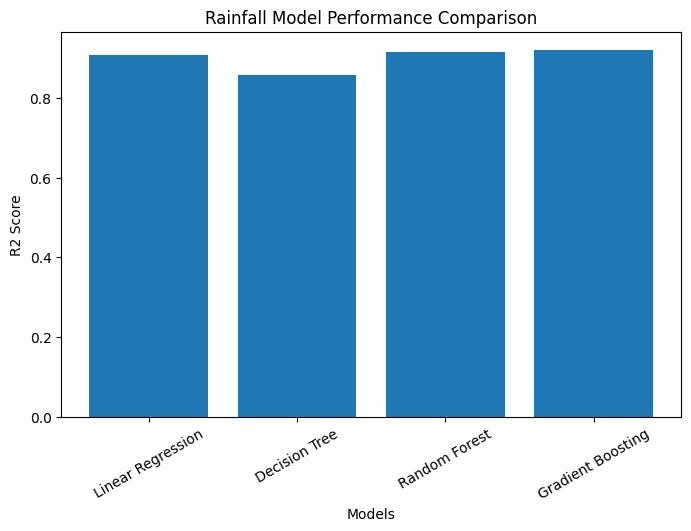

In [6]:
plt.figure(figsize=(8,5))

plt.bar(models.keys(), scores)

plt.title("Rainfall Model Performance Comparison")

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.xticks(rotation=30)

plt.show()

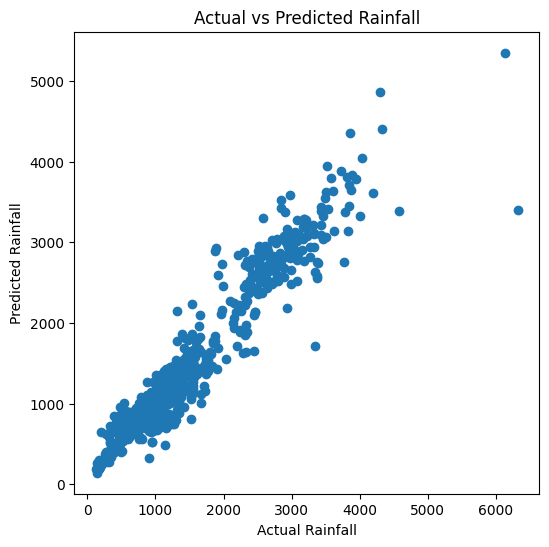

In [7]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rainfall")

plt.ylabel("Predicted Rainfall")

plt.title("Actual vs Predicted Rainfall")

plt.show()

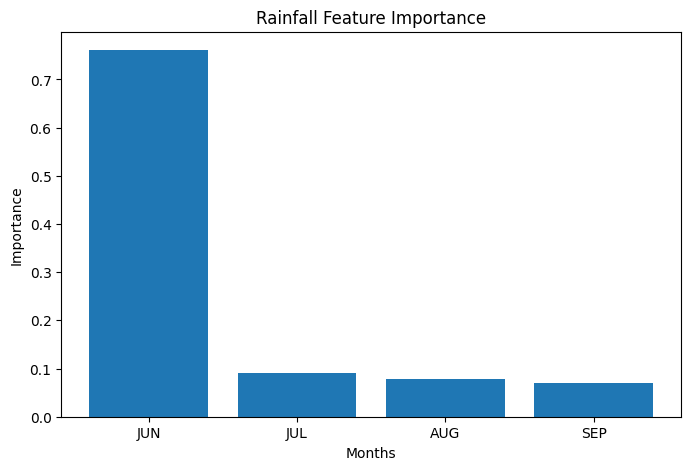

In [8]:
importance = rf.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(X.columns, importance)

plt.title("Rainfall Feature Importance")

plt.xlabel("Months")

plt.ylabel("Importance")

plt.show()